In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the taxis dataset
df = sns.load_dataset("taxis")

df.head()

Matplotlib is building the font cache; this may take a moment.


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [3]:
df.isnull().sum()[df.isnull().sum() > 0]

payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [4]:
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])

df["payment"].isnull().sum()

np.int64(0)

In [5]:
df["pickup_borough"] = df["pickup_borough"].fillna(
    df["pickup_borough"].mode()[0]
)

df["pickup_borough"].isnull().sum()

np.int64(0)

In [6]:
df["dropoff_borough"] = df["dropoff_borough"].fillna(
    df["dropoff_borough"].mode()[0]
)

df["dropoff_borough"].isnull().sum()

np.int64(0)

In [7]:
df["pickup_zone"] = df["pickup_zone"].fillna(
    df["pickup_zone"].mode()[0]
)

df["pickup_zone"].isnull().sum()

np.int64(0)

In [8]:
df["dropoff_zone"] = df["dropoff_zone"].fillna(
    df["dropoff_zone"].mode()[0]
)

df["dropoff_zone"].isnull().sum()

np.int64(0)

In [9]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [10]:
df["pickup"] = pd.to_datetime(df["pickup"])

df["pickup"].dtype

dtype('<M8[us]')

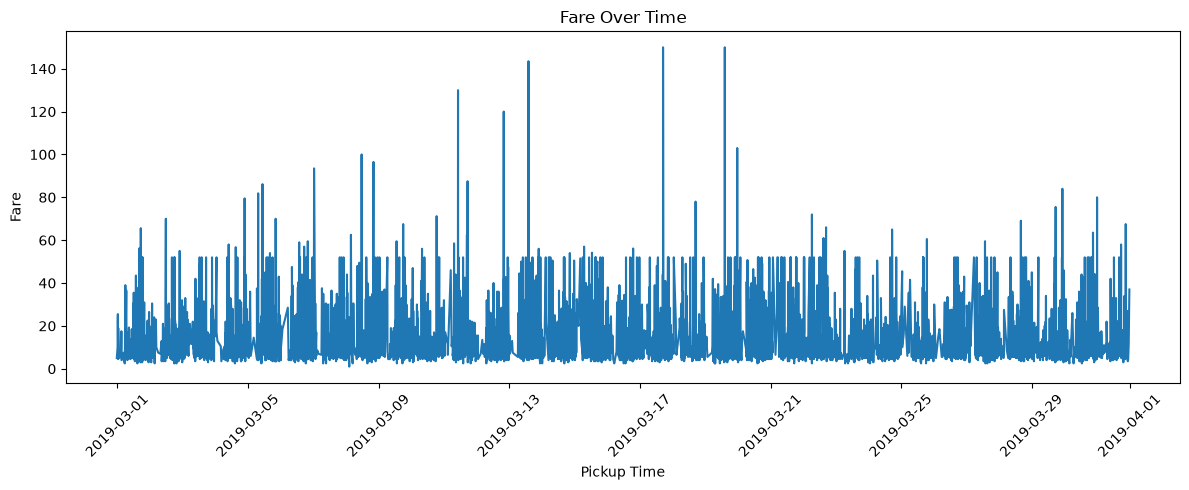

In [12]:
df = df.sort_values("pickup")

plt.figure(figsize=(12, 5))

plt.plot(df["pickup"], df["fare"])

plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

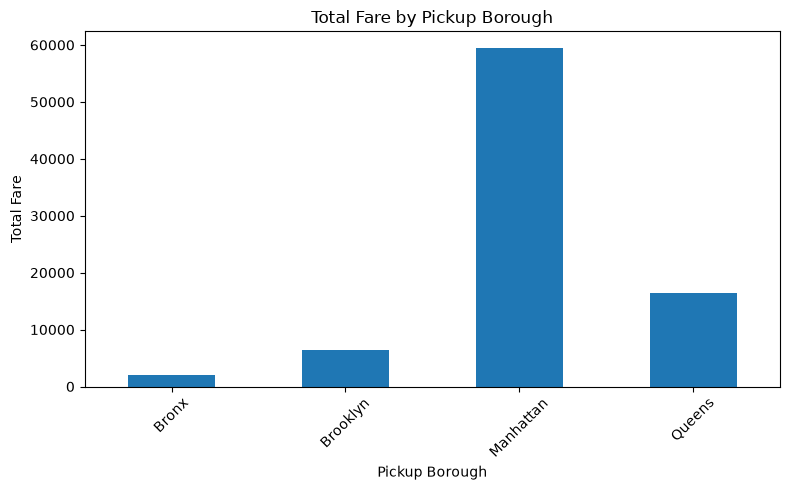

In [13]:
fare_by_borough = df.groupby("pickup_borough")["fare"].sum()

fare_by_borough.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

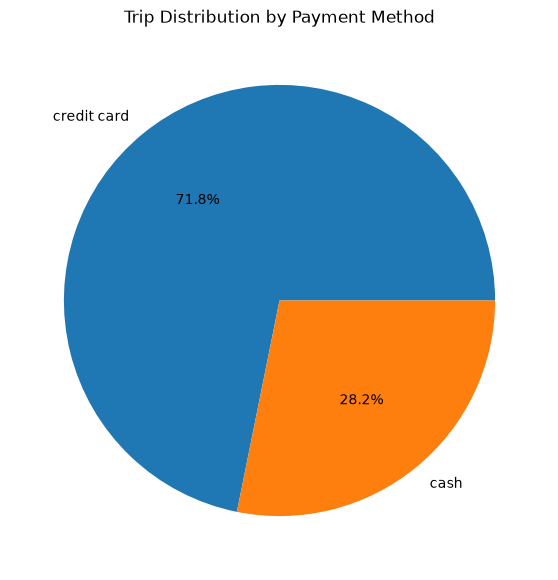

In [14]:
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Trip Distribution by Payment Method")

plt.show()

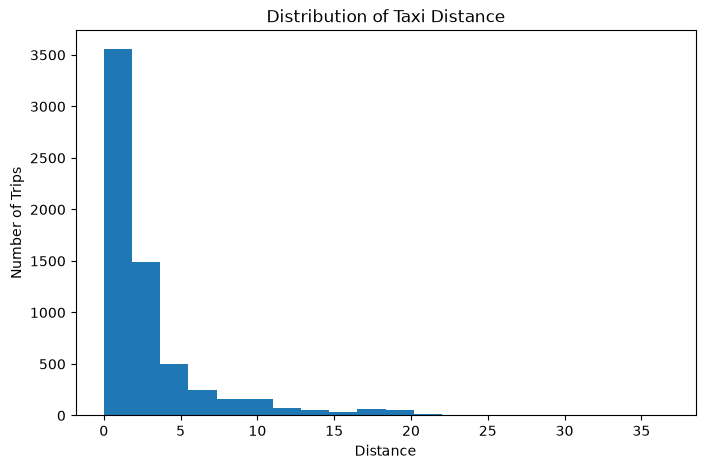

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["distance"], bins=20)

plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Taxi Distance")

plt.show()

<Figure size 1000x500 with 0 Axes>

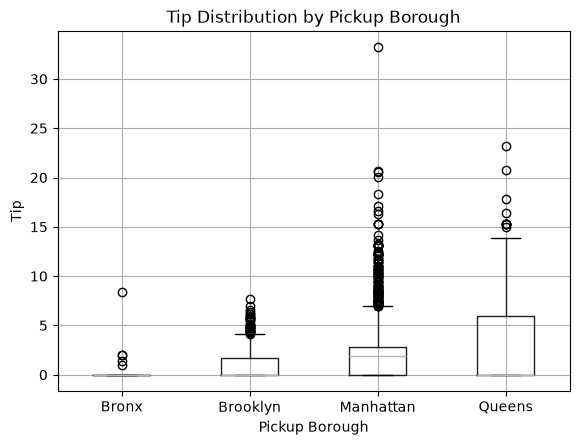

In [16]:
plt.figure(figsize=(10, 5))

df.boxplot(column="tip", by="pickup_borough")

plt.xlabel("Pickup Borough")
plt.ylabel("Tip")
plt.title("Tip Distribution by Pickup Borough")

plt.suptitle("")

plt.show()

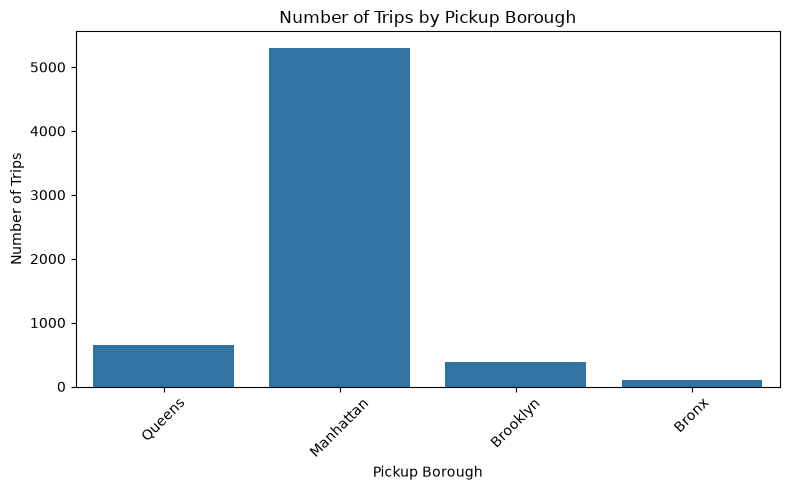

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="pickup_borough")

plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

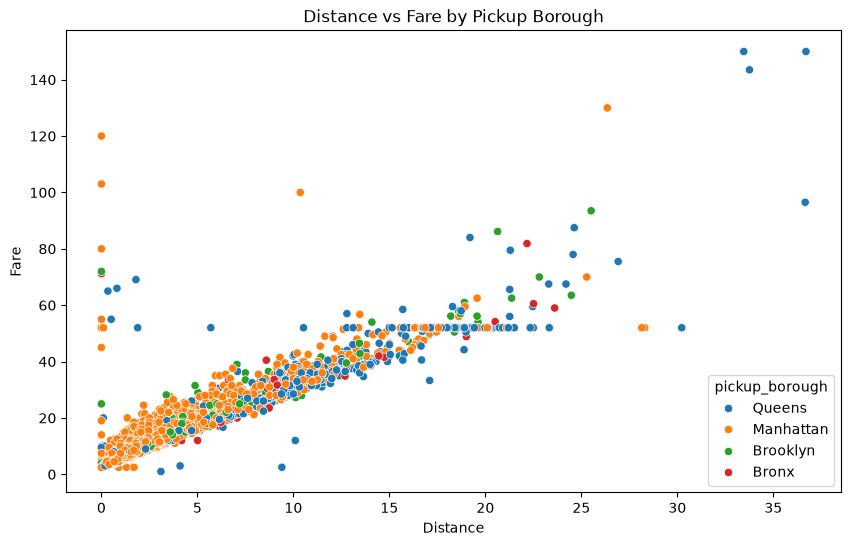

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Distance vs Fare by Pickup Borough")

plt.show()

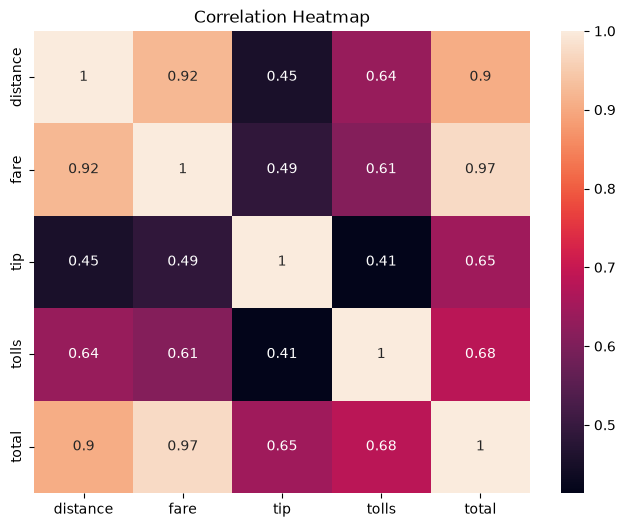

In [19]:
corr = df[["distance", "fare", "tip", "tolls", "total"]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

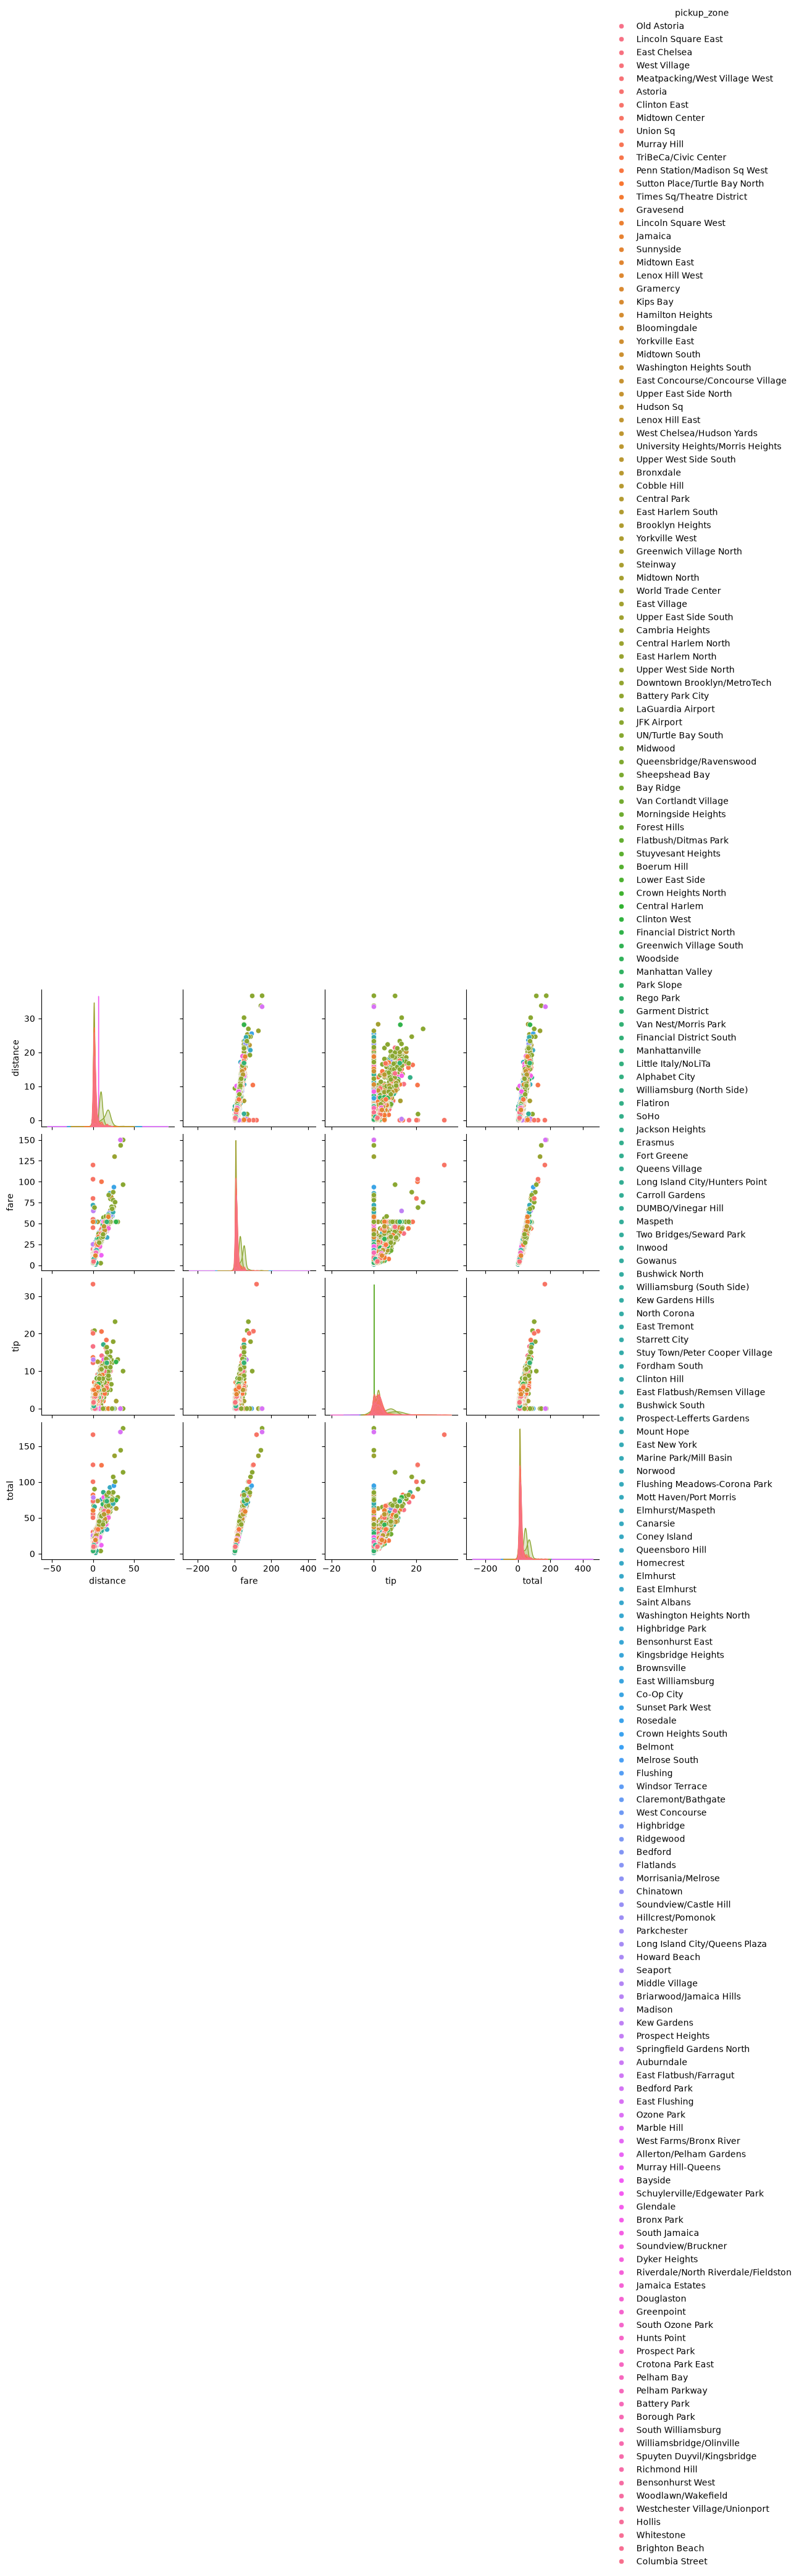

In [20]:
sns.pairplot(
    df[["distance", "fare", "tip", "total", "pickup_zone"]].dropna(),
    hue="pickup_zone"
)

plt.show()

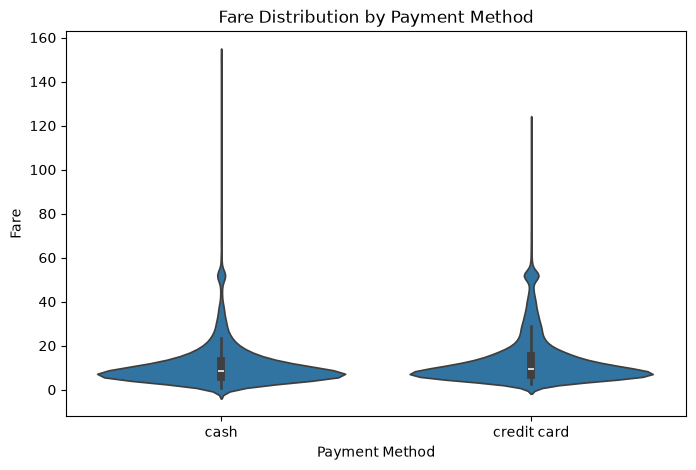

In [21]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="payment",
    y="fare"
)

plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.title("Fare Distribution by Payment Method")

plt.show()